In [ ]:
#IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
#Load dataset
df=pd.read_csv("/content/Crop_recommendation.csv")
print("Dataset Loaded Succesfully")

Dataset Loaded Succesfully


In [ ]:
df.shape

(2200, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Nitrogen     2200 non-null   int64  
 1   phosphorus   2200 non-null   int64  
 2   potassium    2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
 8   Unnamed: 8   0 non-null      float64
 9   Unnamed: 9   0 non-null      float64
dtypes: float64(6), int64(3), object(1)
memory usage: 172.0+ KB


In [ ]:
df.describe()

,Nitrogen,phosphorus,potassium,temperature,humidity,ph,rainfall,Unnamed: 8,Unnamed: 9
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,0.0,0.0
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655,NaN,NaN
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389,NaN,NaN
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267,NaN,NaN
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686,NaN,NaN
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624,NaN,NaN
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508,NaN,NaN
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117,NaN,NaN


In [ ]:
df.head()

,Nitrogen,phosphorus,potassium,temperature,humidity,ph,rainfall,label,Unnamed: 8,Unnamed: 9
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,NaN,NaN
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,NaN,NaN
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,NaN,NaN
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,NaN,NaN
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,NaN,NaN


In [ ]:
duplicate=df.duplicated().sum()
print("No.of Duplicates: ",duplicate)

No.of Duplicates:  0


In [ ]:
df.isnull().sum()

,0
Nitrogen,0
phosphorus,0
potassium,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0
Unnamed: 8,2200
Unnamed: 9,2200


In [ ]:
import pandas as pd
import numpy as np
#Features Summary
numerical_features=df.select_dtypes(include=[np.number]).columns
categorical_features=df.select_dtypes(include=[object]).columns
print("Feature Summary:\n")
print("Numerical Features:")
for col in numerical_features:
  print("-", col)
print("\nCategorical Features:")
for col in categorical_features:
  print("-", col)

Feature Summary:

Numerical Features:
- Nitrogen
- phosphorus
- potassium
- temperature
- humidity
- ph
- rainfall
- Unnamed: 8
- Unnamed: 9

Categorical Features:
- label


In [ ]:
#LabelE
label_encoder=LabelEncoder()
df['label']=label_encoder.fit_transform(df['label'])

In [ ]:
# Separate Features and Target
# x includes all columns except 'label', 'Unnamed: 8', and 'Unnamed: 9'
x = df.drop(columns=['label', 'Unnamed: 8', 'Unnamed: 9'])

# y is the 'label' column
y = df['label']

In [ ]:
#split the dataset into training and testing
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
#Model Building
model=DecisionTreeClassifier(criterion='entropy')
model.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy')

In [ ]:
#predictions
y_pred=model.predict(x_test)

In [ ]:
#Evalution metrics
accuracy=accuracy_score(y_test,y_pred)
confus_matrix=confusion_matrix(y_test,y_pred)
class_rep=classification_report(y_test,y_pred)
print("Accuracy: ",accuracy)
print("Confusion Matrix: ",confus_matrix)
print("Classification Report: ",class_rep)

Accuracy:  0.9795454545454545
Confusion Matrix:  [[23  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 21  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 26  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 26  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 14  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 21  0  0  0  0  0  0  0  0  0  0  0  2  0]
 [ 0  0  0  0  0  0  0  0  0 19  0  0  0  1  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 11  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 21  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  1  0  0 23  0  0  0  

In [ ]:
#training Accuracy
y_train_pred=model.predict(x_train)
train_accuracy=accuracy_score(y_train,y_train_pred)
print("Training Accuracy: ",train_accuracy)
#Testing Accuracy
y_test_pred=model.predict(x_test)
test_accuracy=accuracy_score(y_test,y_test_pred)
print("Testing Accuracy: ",test_accuracy)

Training Accuracy:  1.0
Testing Accuracy:  0.9795454545454545


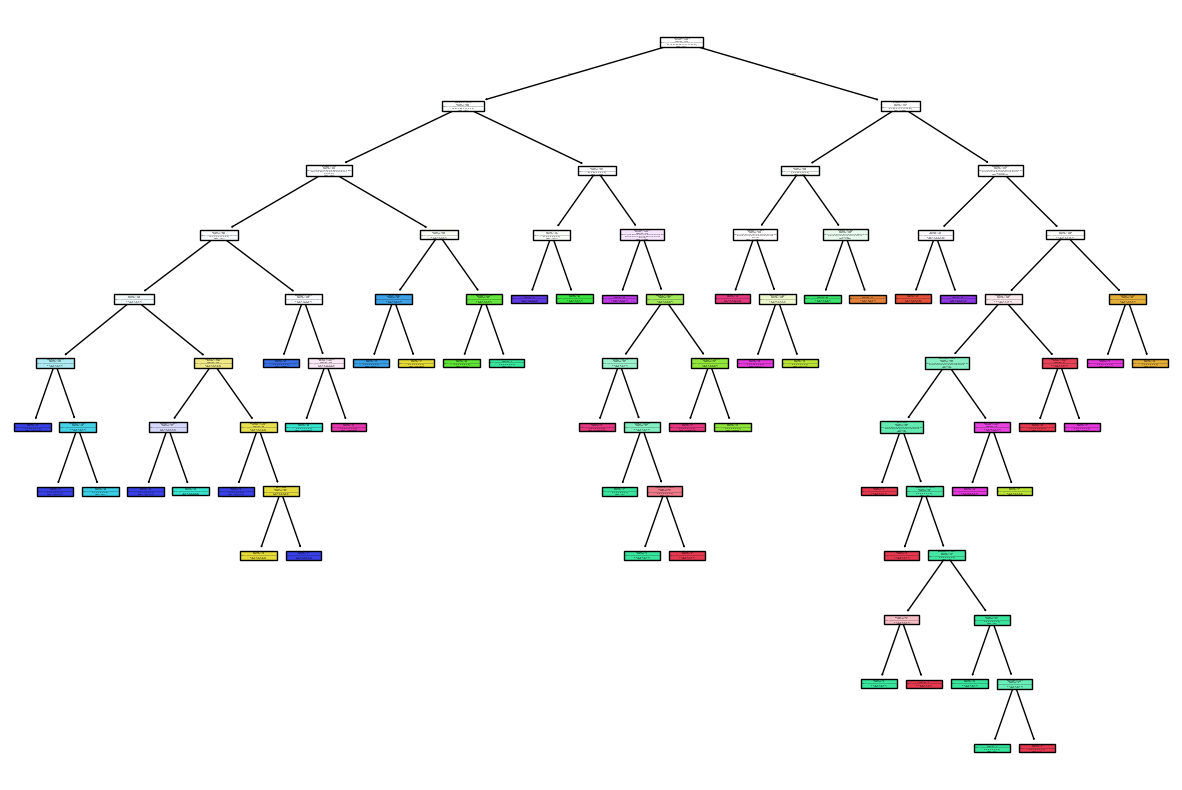

In [ ]:
#display decision tree
from sklearn.tree import plot_tree
plt.figure(figsize=(15,10))
plot_tree(model,filled=True,feature_names=x.columns,class_names=label_encoder.classes_)
plt.show()

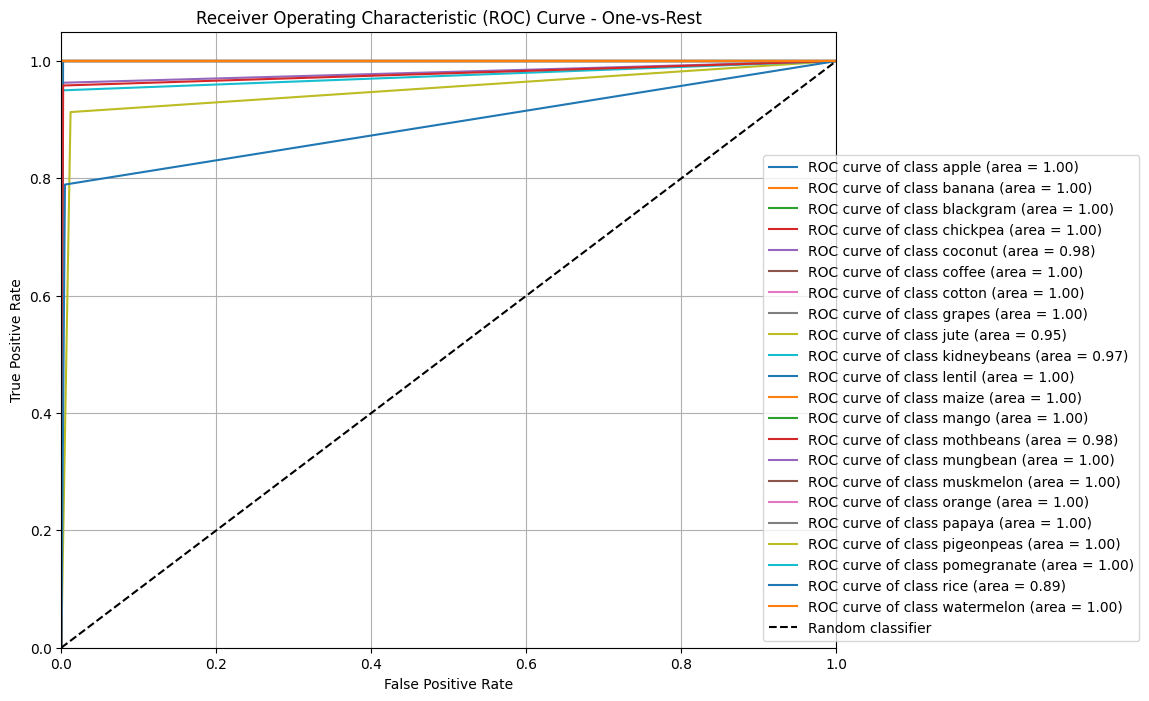

In [ ]:
# Get predicted probabilities for each class
y_pred_proba = model.predict_proba(x_test)

# Get the number of classes
n_classes = len(label_encoder.classes_)

plt.figure(figsize=(10, 8))

# Plot ROC curve for each class
for i in range(n_classes):
    # Binarize y_test for the current class
    y_test_binarized = (y_test == i).astype(int)

    # Calculate FPR, TPR, and thresholds for the current class
    fpr, tpr, thresholds = roc_curve(y_test_binarized, y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'ROC curve of class {label_encoder.classes_[i]} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random classifier') # Dashed diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - One-vs-Rest')
plt.legend(loc="lower right", bbox_to_anchor=(1.4, 0))
plt.grid(True)
plt.show()

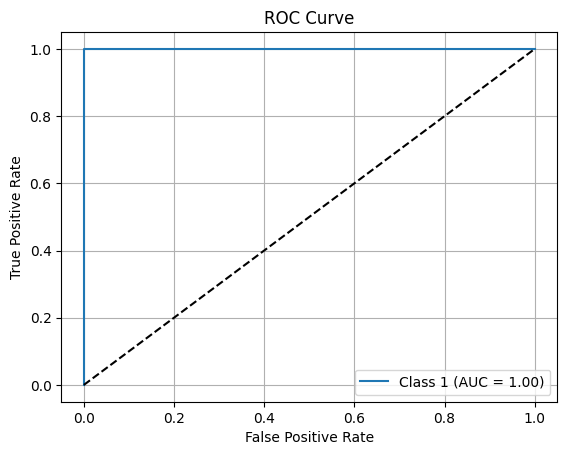

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predicted probabilities
y_pred_proba = model.predict_proba(x_test)

# Select class 1
y_test_binary = (y_test == 1).astype(int)

# Probability of class 1
y_score = y_pred_proba[:, 1]

# Calculate ROC
fpr, tpr, thresholds = roc_curve(y_test_binary, y_score)

# AUC
roc_auc = auc(fpr, tpr)

# Plot
plt.plot(fpr, tpr, label=f'Class 1 (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()